# Notes from AIAMA20 Chapter 3 Solving Problems by Searching

## Problem Solving Agent
- when correct action to take is not immediately obvious -- plan ahead -- consdier a sequence of actions that form a path to a goal state
    - this computational process is called **search**
    - uses **atomic** representations - no view into internal structure (states)
- Agents taht use factored/structured representations of states --> **planning gagents**
- Factors:
    - episodic or continuing
    - single or multi-agent
    - Fully or partially observable
    - Deterministic or Stochastic
    - Static or Dynamic
    - Discrete or Continuous
    - Known or Unknown
For example:

    - Classical planning: episodic, single-agent, fully observable, deterministic, static, discrete, known.
    - RL: often continuing, stochastic, unknown.
    - robotics: often continuous and partially observable.
    - Games: multi-agent and stochastic.
- Informed agents - can estimate how far from goal
    -- vs uninformed agents -- no estimate available
- Steps:
    1. Goal formulation
    2. Problem formulation - description of states and actions necessary to reach goal
    3. Search - simulating sequences of actions
    4. Execution
- **Fully observable, deterministic, known environments, the solution to any problem is a fixed sequence of actions**
- Open-loop - ignoring percepts breaks the loop between agent and environment 
    - so loop is broken -- aka open loop
    - *We do this above mentioned environments*
- Closed loop - monitors the percepts if chance that the model is incorrect or environment is non-deterministic
- Must **abstract** and remove detail from required problem solving process


## Search Algorithms

**Superimposing a search tree over the state-space graph, forming various paths from initial state, trying to find a path that reaches a goal state**

- State space: describes the (possibly infinite) set of states in the world and the actions that allow transitions from one state to another
- Search tree: describes paths b/w these states, reaching towards the goal
- Graph search: checks for redundant paths
- Tree-like search: does not check for redundant paths


## Dijkstra vs. Uniform-Cost Search — Complexity Summary

## Same Algorithm, Different Names

Best-first search with evaluation function:

$f(n) = g(n)$

where $g(n)$ is the path cost from the root.

- Theoretical CS → **Dijkstra’s Algorithm**
- AI community → **Uniform-Cost Search (UCS)**

They are the same algorithm. The difference is in how they are analyzed.

---

## Behavior

- BFS expands in waves of **equal depth**.
- UCS/Dijkstra expands in waves of **equal path cost**.

Instead of depth layers:
$d = 1, 2, 3$

UCS expands by cost layers:
$c = 1, 2, 3$

---

## Graph-Theoretic Complexity

Assume:
- Finite graph
- $V$ vertices
- $E$ edges
- No duplicate state generation

Time complexity:

$O((V + E)\log V)$

Polynomial and efficient.

---

## AI Search Tree Complexity

Assume:
- Implicit search tree
- Branching factor $b$
- Optimal solution cost $C^*$
- Minimum step cost $\epsilon > 0$

Worst-case time and space:

$O\left(b^{1 + \lfloor C^*/\epsilon \rfloor}\right)$

Why?

Because UCS may generate all nodes whose path cost is less than $C^*$.

Maximum depth before exceeding $C^*$ is:

$\left\lfloor \frac{C^*}{\epsilon} \right\rfloor$

If $\epsilon$ is small, this can be very large → exponential growth.

---

## When UCS Equals BFS

If all edge costs are equal:

$\epsilon = 1$

Then:

$C^* = d$

So complexity becomes:

$O(b^{1+d})$

Which matches BFS.

---

## Key Insight

No contradiction exists between:

$O(E \log V)$

and

$O\left(b^{1 + \lfloor C^*/\epsilon \rfloor}\right)$

They analyze:

- A finite graph (algorithms view)
- An implicit search tree (AI view)

Same algorithm. Different abstraction models.


## Informed Search -- Heuristic Search Strategies

- Greedy best-first search is a form of heuristic -- choose node that appears to be the closest to the goal on  the ground that this is likely to lead to a solution quickly
    - Example is using straight line distances for route finding

### A* Search
- Uses eval function $f(n) = g(n) + h(n)$
- $g(n)$ is the path cost from initial state to node $n$ and $h(n)$ is the estimated cost of the shortest path from $n$ to goal state
- $f(n)$ = estimated cost of the best path that continues from $n$ to a goal
- A* is cost-optimal if we use an **admissible heuristic**
    - Admissible heuristic - one that never overestimated cost to reach a goal -> is an optimistic heuristic
**Consistency** - heuristic is consisten tif for every node $n$ and every successor $n'$ of $n$ generated by an action $a$, we have $h(n) \le c(n,a,n') + h(n')$
    - If the heuristic $h$ is consistent, then the single number $h(n)$ will be less than the sum of the cost $c(n,a,a')$ of the action from $n$ to $n'$ plus the heuristic estimate $h(n')$
    - This is a form of the triangle inequality -- a side of a triangle cannot be longer than the sum of the other two sides
    - Straight-line distance is an example of a consistent heuristic
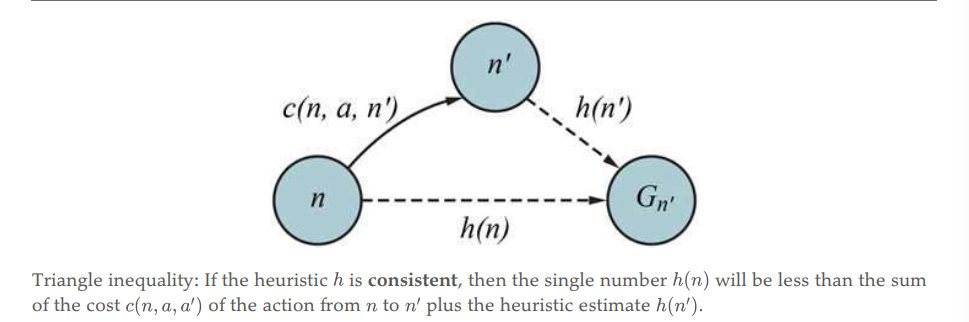
**Cost-optimal** - algorithm is guaranteed to return a solution whose total path cost is minimal among all possible solutions
- With inconsistent heuristic may end up with multiple paths reaching the same state
    - worst case effects rarely happen in practice
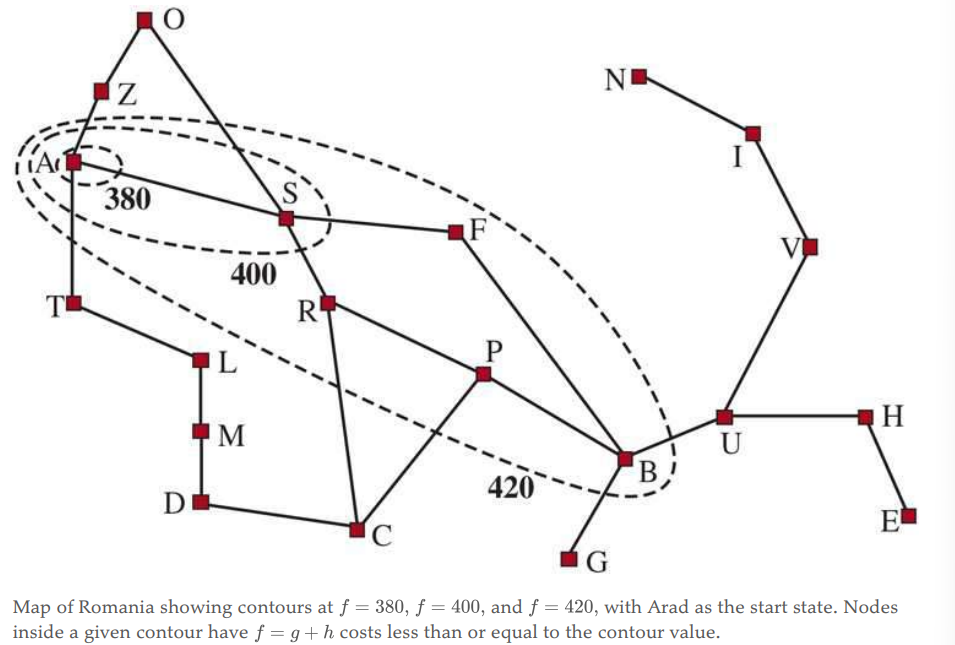
- A* is efficient because it **prunes** away search tree nodes that are not necessary for finding an optimal solution
    - synonomous to eliminating possibilities from consideration -- important for AI
- Monotonic heuristic is synonym for consistent heuristic - refer to the contour visual
    - A* expands all nodes that can be reached from initial state on a path where every nodes on path has $f(n) < C*$, where $C*$ is the cost of the optimal solution path
**Satisficing** - willing to accept solutions that are suboptimal but are "good enough"
    - can do this with A* by using an inadmissible heuristic - one that may overestimate
    - gives weighted A* search -> $f(n) = g(n) + W x h(n)$ for some $W > 1$
- 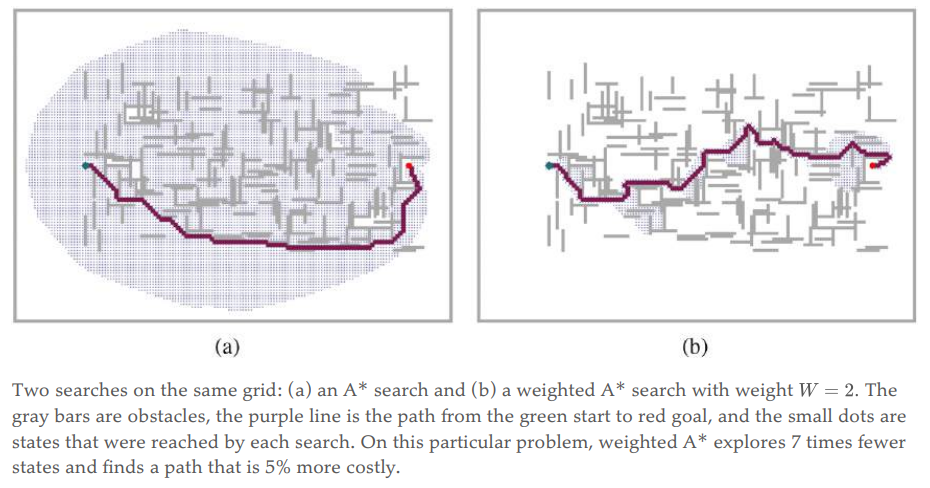    
- Beam search is a form of pruning strategy
- Bidirectional search is sometimes more efficient than unidirectional search, sometimes not. In general, if we have a very good heuristic, then A* search produces search contours that are focused on the goal, and adding bidirectional search does not help much. With an average heuristic, bidirectional search that meets in the middle tends to expand fewer nodes and is preferred. In the worst case of a poor heuristic, the search is no longer focused on the
goal, and bidirectional search has the same asymptotic complexity as A*. Bidirectional search with the evaluation function and an admissible heuristic is complete and
optimal.